<a href="https://colab.research.google.com/github/olorunfemibabalola/Research-Methods-DSAI/blob/main/2405023Lab_7_RMDAI_Activity_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Development From the Scratch**

# **Activity-1:  Creating a Single-Layer Neural Network**

For this activity, we will create a single-layer neural network, which will be a starting
point from which we will create deep neural networks in future activities.

Let's look at the following scenario:

# **Scenario:**

You work as an assistant of the mayor of Somerville and the HR department has
asked you to build a model capable of predicting whether a person is happy with
the current administration based on their satisfaction with the city's services. To do
so, you have decided to build a single-layer neural network using PyTorch, using the
response of previous surveys. Perform the following steps to complete this activity:

# **Dataset:**

The dataset that's being used for this activity was taken from the UC Irvine
Machine Learning Repository, which can be downloaded using the following
URL, from the Data Folder hyperlink:

https://archive.ics.uci.edu/ml/datasets/Somerville+Happiness+Survey




# Task-1 Import the required libraries, including pandas for reading a CSV file.

In [93]:
#Write your code

# Step 1: Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt


# Task-2: Read the CSV file containing the dataset

In [94]:
# Reading the dataset file from local machine
# Write your code
file = 'SomervilleHappinessSurvey2015.csv'
df = pd.read_csv(file, encoding = 'utf-16')

print("Dataset Preview: \n", df.head(), "\n")

Dataset Preview: 
    D  X1  X2  X3  X4  X5  X6
0  0   3   3   3   4   2   4
1  0   3   2   3   5   4   3
2  1   5   3   3   3   3   5
3  0   5   4   3   3   3   5
4  0   5   4   3   3   3   5 



# Task-3: Separate the input features from the target. Note that the target is located in the first column of the dataset file. Next, convert the values into tensors, making sure the values are converted into floats.

In [95]:
# Step 3: Separate input features and target

# Target is in the first column, features in the remaining columns
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values


# Convert to PyTorch tensors (float type)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)


# Task-4: Define the architecture of the model and store it in a variable named **"model"**.

# Note: Remember to create a single-layer model.

In [96]:
# Step 4: Define the model architecture (Single-layer neural network)
# Input size = number of features, Output size = 1

input_size = X.shape[1]
output_size = 1

model = nn.Sequential(
    nn.Linear(input_size, output_size),
    nn.Sigmoid()
)


# Task-5: Define the loss function to be used. In this case, use the MSE loss function.

In [97]:
# Step 5: Define the loss function (Mean Squared Error)
criterion = nn.MSELoss()

# Task-6: Define the optimizer of your model.

# In this case, use the Adam optimizer and a learning rate of 0.01.

In [98]:
# Step 6: Define the optimizer (Adam, learning rate = 0.01)

optimizer = optim.Adam(model.parameters(), lr=0.01)

# Task-7: Model Training

Run the optimization for 100 iterations, saving the loss value for each iteration.

Print the loss value every 10 iterations.

In [99]:
# Step 7: Train the model
# Write your code

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(X)
    loss = criterion(y_pred, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.2517
Epoch [20/100], Loss: 0.2474
Epoch [30/100], Loss: 0.2448
Epoch [40/100], Loss: 0.2430
Epoch [50/100], Loss: 0.2417
Epoch [60/100], Loss: 0.2407
Epoch [70/100], Loss: 0.2399
Epoch [80/100], Loss: 0.2393
Epoch [90/100], Loss: 0.2387
Epoch [100/100], Loss: 0.2381


# Task-8: Make a line plot to display the loss value for each iteration step.

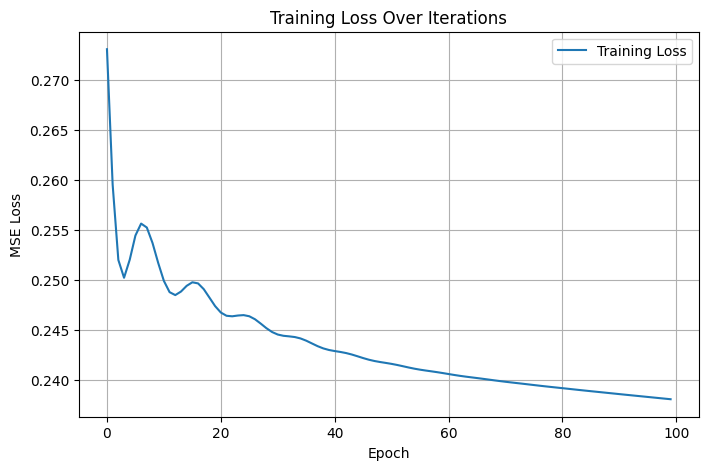

In [100]:
# Step 8: Plot the loss over iterations
# Write you code

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Iterations')

plt.legend()
plt.grid(True)
plt.show()

# Task-9: Make predictions on the training data

In [101]:
# Write you code
with torch.no_grad():
    predictions = model(X)
    predicted_classes = (predictions >= 0.5).float()
    accuracy = (predicted_classes == y).sum().item() / y.size(0)
    print(f"\nTraining Accuracy: {accuracy * 100:.2f}%")

#


Training Accuracy: 60.14%
